# Objective sweep results

Loads a finished (or in-progress) run of `experiments/run_objective_sweep.py`
(or any `experiments.sweep.run_sweep` call) and inspects it: the headline
sim-vs-bounds table, a plot against a swept axis, and how to drop into one
trial's full detail.

The exact model can appear two ways: `exact_*` (compact MILP, when the run
used `run_exact_model=True`) and `bp_*` (branch-and-price on the same model,
`run_bp_model=True`). Every cell below shows whichever of them the run has,
so older runs without `bp_*` columns load unchanged.

Nothing here re-runs the sweep -- it only reads what is already on disk under
`experiments/results/<run_name>/`. See `experiments/README.md` for what each
column means and for the sweep-side gotchas (the window's two edges,
DW's LB-only default, common random numbers across a sweep, etc.).

In [1]:
%load_ext autoreload
%autoreload 2

from __future__ import annotations

import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from experiments.objective_sweep import load_results, comparison_table
from experiments.core import DEFAULT_OUT_DIR
from visualization.style import new_figure, style_axes, style_legend, palette

## Point this at a run

`RUN_NAME` is the sub-directory name you passed as `run_name` to `run_sweep`
(or the auto-generated `sweep_<timestamp>` if you didn't pass one -- check
`experiments/results/` on disk, or the last line `run_sweep` printed, if
you're not sure).

In [19]:
RUN_NAME = "1pile_75kwh_bp"  # <-- edit to the run you want to inspect
OUT_DIR = DEFAULT_OUT_DIR  # where run_sweep wrote it (its out_dir argument)

run_dir = Path(OUT_DIR) / RUN_NAME
df = load_results(RUN_NAME, OUT_DIR)
print(f"{len(df)} trial(s) loaded from {run_dir / 'results.csv'}")

# Which exact-model sources this run has: the compact MILP ("exact") and/or
# branch-and-price ("bp"). Later cells use these to show whichever exist.
HAS_EXACT = "exact_objective" in df.columns
HAS_BP = "bp_objective" in df.columns
print(f"exact MILP columns: {HAS_EXACT}   branch-and-price columns: {HAS_BP}")

# Units of the objective/bound columns (exact_objective, *_best_bound, dw_LB,
# bound_history.csv): total sojourn in minutes. Runs written before the
# models switched objective have no "objective_units" in run_meta.json --
# their objective/bound columns are sum_j D_j in SLOTS instead. Every
# *_mean_sojourn* column is minutes either way, so the plots are unaffected.
OBJECTIVE_UNITS = json.loads((run_dir / "run_meta.json").read_text()).get(
    "objective_units", "sum_D_slots (legacy run)"
)
print(f"objective/bound columns are in: {OBJECTIVE_UNITS}")
df.head()

15 trial(s) loaded from D:\OneDrive - University of Toronto\Uni\Ph.D\Thesis\Chapter 2 - Queueing\Python Codes\experiments\results\1pile_75kwh_bp\results.csv
exact MILP columns: False   branch-and-price columns: True


,trial_id,n_piles,n_connectors,n_modules,p_module,queue_capacity,mean_interarrival,max_time,warmup_period,flush_queue_at_warmup,...,dw_mean_sojourn_LB,dw_UB,dw_gap,dw_total_sojourn_UB,dw_mean_sojourn_UB,dw_whole_module_feasible,dw_n_vehicles,dw_n_optimized,dw_K,dw_runtime_s
0,0,1,2,6,25.0,1000,7.500000,240,360,False,...,133.656203,NaN,NaN,NaN,NaN,NaN,51,51,120,513.985961
1,1,1,2,6,25.0,1000,8.000000,240,360,False,...,122.135031,NaN,NaN,NaN,NaN,NaN,49,49,120,375.209296
2,2,1,2,6,25.0,1000,8.571429,240,360,False,...,130.183885,NaN,NaN,NaN,NaN,NaN,40,40,120,337.431499
3,3,1,2,6,25.0,1000,9.230769,240,360,False,...,120.401073,NaN,NaN,NaN,NaN,NaN,37,37,120,333.399282
4,4,1,2,6,25.0,1000,10.000000,240,360,False,...,107.601147,NaN,NaN,NaN,NaN,NaN,35,35,120,316.852635


## Run metadata

`run_meta.json` records the sweep definition and timing: every `TrialConfig`
that was queued (as a dict, via `to_row()`), which stages
(`sim`/`exact`/`bp`/`dw`) were switched on, and start/finish/total runtime.
Runs made before branch-and-price existed have no `bp` entry.

In [3]:
meta = json.loads((run_dir / "run_meta.json").read_text())
print("stages run:", meta["stages"])
print("n_trials:  ", meta["n_trials"])
print("started:   ", meta["started"], " finished:", meta.get("finished", "(in progress)"))
if "total_runtime_s" in meta:
    print(f"total runtime: {meta['total_runtime_s']:.1f} s")

stages run: {'sim': True, 'exact': False, 'bp': True, 'dw': True}
n_trials:   15
started:    2026-09-30T22:21:29  finished: 2026-10-01T05:41:35
total runtime: 26405.7 s


## Headline view: sim vs. grid vs. exact / B&P vs. DW's lower bound

`comparison_table` pulls out every source's mean sojourn for one cohort
(default `"all"`) alongside the knobs that identify each row.

**`group` is the important argument.** Every source now reports two
populations:

* `"arrived"` (the default) -- every vehicle the models were given, with
  unfinished ones censored at the horizon. All columns cover the same set,
  so this is the one to compare on.
* `"completed"` -- only vehicles that received their full energy. Readable,
  but it conditions on an outcome: it drops precisely the longest sojourns,
  and the simulation and the models drop *different* vehicles.

Comparing a `completed` number against an `arrived` one is what makes a
proven optimum look *worse* than feasible FIFO. The `sim_n`/`grid_n`/
`exact_n`/`bp_n` columns are shown so any residual mismatch stays visible.

Remember `sim` is continuous-time and NOT the like-for-like target -- compare
against `grid` (that same schedule replayed on the `delta` slot grid).
`exact` is the MILP's incumbent; `bp` / `bp_LB` are branch-and-price's best
schedule and proven lower bound for the same model (equal when
`bp_status == "OPTIMAL"`); `dw_LB` is DW's certified lower bound. On every
row you should see `grid >= exact >= bp_LB`, `bp >= bp_LB`, and
`dw_LB <= ` the true optimum.

In [15]:
GROUP = "arrived"   # "arrived" (comparable) | "completed" (finished only)

table = comparison_table(df, cohort="all", group=GROUP)
table

,mean_interarrival,max_time,delta,mip_gap,gap_tolerance,sim,grid,exact,dw_LB,sim_n,grid_n,exact_n,exact_status,dw_status,sim_runtime_s,exact_runtime_s,dw_runtime_s
0,10.000000,120,2.0,0.0010,0.000001,81.773347,82.320000,77.680000,76.141436,25.0,25.0,25.0,TIME_LIMIT,CONVERGED,0.043137,7199.295704,62.221100
1,10.909091,120,2.0,0.0010,0.000001,66.282356,67.181818,65.727265,62.741019,22.0,22.0,22.0,TIME_LIMIT,CONVERGED,0.046025,7200.427915,68.279585
2,12.000000,120,2.0,0.0010,0.000001,67.260050,67.882353,62.823529,60.605887,17.0,17.0,17.0,TIME_LIMIT,CONVERGED,0.055485,7200.472458,65.059266
3,13.333333,120,2.0,0.0010,0.000001,63.663306,64.769231,58.153839,55.978519,13.0,13.0,13.0,TIME_LIMIT,CONVERGED,0.059544,5400.222075,36.797745
4,15.000000,120,2.0,0.0010,0.000001,47.140645,48.153846,43.384615,41.180640,13.0,13.0,13.0,TIME_LIMIT,CONVERGED,0.042044,3600.178526,51.898971
5,17.142857,180,2.0,0.0001,0.000001,50.246608,51.428571,51.571428,42.826565,14.0,14.0,14.0,TIME_LIMIT,CONVERGED,0.074322,1800.286673,95.824552
6,20.000000,180,2.0,0.0001,0.000001,36.318412,37.000000,34.666667,32.759078,12.0,12.0,12.0,TIME_LIMIT,CONVERGED,0.029054,1800.187048,40.678283
7,24.000000,240,1.0,0.0001,0.000001,40.111402,40.454545,39.818182,36.547234,11.0,11.0,11.0,TIME_LIMIT,CONVERGED,0.027429,1800.473917,151.527631
8,30.000000,240,1.0,0.0001,0.000001,32.987891,33.500000,31.166667,29.947341,6.0,6.0,6.0,TIME_LIMIT,CONVERGED,0.013648,1800.179699,86.094493
9,40.000000,240,1.0,0.0001,0.000001,18.707298,19.000000,18.833333,18.647640,6.0,6.0,6.0,OPTIMAL,CONVERGED,0.009659,1.452394,10.597634


## All columns

`results.csv` is wide (config knobs + populations + per-source, per-cohort
metrics -- see the README's column-group table). Group by prefix to see
what's available for a given source.

In [21]:
bracket_cols = [
    'mean_interarrival',
    'exact_objective', 'exact_best_bound', 'exact_mip_gap_achieved', 'exact_runtime_s',
    'bp_status', 'bp_objective', 'bp_best_bound', 'bp_rel_gap', 'bp_nodes',
    'bp_seed_source', 'bp_incumbent_source', 'bp_runtime_s',
    'dw_gap_tolerance_used', 'dw_LB', 'dw_z_rmp', 'dw_rmp_gap', 'dw_runtime_s',
]
df[[c for c in bracket_cols if c in df.columns]]  # columns of stages this run skipped are left out

,mean_interarrival,bp_status,bp_objective,bp_best_bound,bp_rel_gap,bp_nodes,bp_seed_source,bp_incumbent_source,bp_runtime_s,dw_gap_tolerance_used,dw_LB,dw_z_rmp,dw_rmp_gap,dw_runtime_s
0,7.500000,TIME_LIMIT,5314.0,5142.033792,0.032361,120,simulation,restricted integer master (after 50 nodes),1803.280960,2.550000,5121.233177,5123.462630,2.229453e+00,513.985961
1,8.000000,TIME_LIMIT,5096.0,4934.740637,0.031644,154,simulation,restricted integer master (after 50 nodes),1802.673286,2.450000,4914.308262,4916.726981,2.418719e+00,375.209296
2,8.571429,TIME_LIMIT,4063.0,3899.232589,0.040307,160,simulation,restricted integer master (after 50 nodes),1802.090304,2.000000,3879.677691,3881.452140,1.774449e+00,337.431499
3,9.230769,TIME_LIMIT,3603.0,3433.001976,0.047182,180,simulation,restricted integer master (after 50 nodes),1801.839703,1.850000,3415.419853,3417.003114,1.583261e+00,333.399282
4,10.000000,TIME_LIMIT,3405.0,3244.119636,0.047248,180,simulation,restricted integer master (after 50 nodes),1801.676569,1.750000,3225.020080,3226.320917,1.300838e+00,316.852635
5,10.909091,TIME_LIMIT,2589.0,2453.476667,0.052346,205,simulation,restricted integer master (after 50 nodes),1801.389353,1.400000,2435.183628,2436.494100,1.310472e+00,282.902985
6,12.000000,TIME_LIMIT,2389.0,2267.023262,0.051058,222,simulation,greedy list schedule,1801.136915,1.300000,2248.306106,2249.517689,1.211583e+00,222.336801
7,13.333333,TIME_LIMIT,607.0,591.753293,0.025118,859,simulation,restricted integer master (after 500 nodes),1800.285412,0.650000,583.110153,583.655397,5.452436e-01,26.685668
8,15.000000,TIME_LIMIT,1467.0,1384.137407,0.056484,260,simulation,initial schedule,1800.735370,0.950000,1364.501548,1365.239343,7.377946e-01,114.056656
9,17.142857,TIME_LIMIT,1270.0,1214.461260,0.043731,320,simulation,greedy list schedule,1800.573587,0.000001,1196.509939,1196.509939,-1.136868e-12,112.070752


In [6]:
prefixes = ["inst_", "sim_", "grid_", "exact_", "bp_", "dw_"]
for p in prefixes:
    cols = [c for c in df.columns if c.startswith(p)]
    print(f"{p:8s} ({len(cols)} columns): {cols}")

inst_    (8 columns): ['inst_n_vehicles', 'inst_n_dropped_late_arrivals', 'inst_n_optimized', 'inst_n_boundary_vehicles', 'inst_n_discarded', 'inst_n_measurement', 'inst_n_queued', 'inst_n_boundary']
sim_     (23 columns): ['sim_clock_end', 'sim_runtime_s', 'sim_completed_measurement_n', 'sim_completed_measurement_total_sojourn', 'sim_completed_measurement_mean_sojourn', 'sim_completed_measurement_queued_n', 'sim_completed_measurement_queued_total_sojourn', 'sim_completed_measurement_queued_mean_sojourn', 'sim_completed_all_n', 'sim_completed_all_total_sojourn', 'sim_completed_all_mean_sojourn', 'sim_arrived_measurement_n', 'sim_arrived_measurement_n_censored', 'sim_arrived_measurement_total_sojourn', 'sim_arrived_measurement_mean_sojourn', 'sim_arrived_measurement_queued_n', 'sim_arrived_measurement_queued_n_censored', 'sim_arrived_measurement_queued_total_sojourn', 'sim_arrived_measurement_queued_mean_sojourn', 'sim_arrived_all_n', 'sim_arrived_all_n_censored', 'sim_arrived_all_total

## Plot: mean sojourn vs. a swept knob

Edit `X_AXIS` (the column to put on the x-axis) and `GROUP_BY` (one line per
distinct value, or `None` to disable) to match whatever you actually swept.
Color encodes the source (grid / exact / B&P schedule / B&P lower bound /
DW lower bound -- only those the run has); line style encodes the
`GROUP_BY` value.

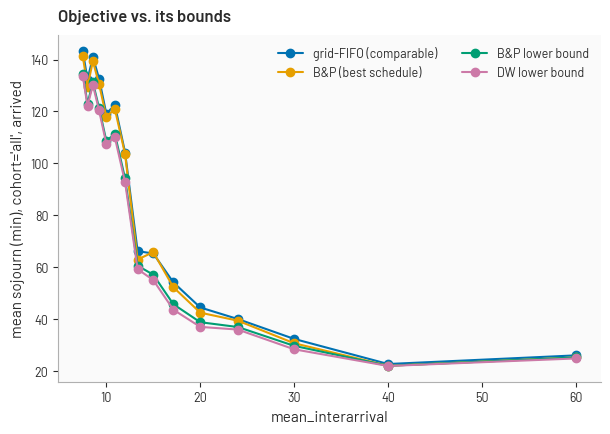

In [22]:
X_AXIS = "mean_interarrival"   # column to put on the x-axis
GROUP_BY = None                # one line per value; set to None to disable
COHORT = "all"                 # "measurement" | "measurement_queued" | "all"
GROUP = "arrived"              # "arrived" (comparable) | "completed"

sources = [
    #(f"sim_{GROUP}_{COHORT}_mean_sojourn", "sim (continuous)"),
    (f"grid_{GROUP}_{COHORT}_mean_sojourn", "grid-FIFO (comparable)"),
    (f"exact_{GROUP}_{COHORT}_mean_sojourn", "exact MILP (incumbent)"),
    (f"bp_{GROUP}_{COHORT}_mean_sojourn", "B&P (best schedule)"),
    ("bp_mean_sojourn_LB", "B&P lower bound"),  # like DW, one bound for objective_cohorts
    ("dw_mean_sojourn_LB", "DW lower bound"),  # DW has no per-cohort LB -- see README
]
sources = [(col, label) for col, label in sources if col in df.columns]
colors = palette(len(sources))
linestyles = ["-", "--", ":", "-."]
groups = sorted(df[GROUP_BY].unique()) if GROUP_BY else [None]

fig, ax = new_figure(figsize=(7, 4.5))
for gi, gval in enumerate(groups):
    sub = df[df[GROUP_BY] == gval].sort_values(X_AXIS) if GROUP_BY else df.sort_values(X_AXIS)
    for (col, label), color in zip(sources, colors):
        line_label = f"{label} ({GROUP_BY}={gval:g})" if GROUP_BY else label
        ax.plot(sub[X_AXIS], sub[col], marker="o", color=color,
                 linestyle=linestyles[gi % len(linestyles)], label=line_label)

ax.set_xlabel(X_AXIS)
ax.set_ylabel(f"mean sojourn (min), cohort='{COHORT}', {GROUP}")
style_axes(ax, title="Objective vs. its bounds")
style_legend(ax, fontsize=7, ncol=2)
plt.show()

,mean_interarrival,max_time,delta,bp_status,dw_status,grid,bp,bp_vs_grid,bp_LB,bp_LB_vs_grid,dw_LB,dw_LB_vs_grid
0,7.50,240,2.0,TIME_LIMIT,CONVERGED,143.29,141.22,1.45,134.47,6.16,133.66,6.73
1,8.00,240,2.0,TIME_LIMIT,CONVERGED,132.20,129.55,2.01,122.97,6.99,122.14,7.62
2,8.57,240,2.0,TIME_LIMIT,CONVERGED,140.95,139.35,1.14,131.16,6.94,130.18,7.64
3,9.23,240,2.0,TIME_LIMIT,CONVERGED,132.59,130.54,1.55,121.35,8.48,120.40,9.20
4,10.00,240,2.0,TIME_LIMIT,CONVERGED,119.14,117.89,1.06,108.69,8.77,107.60,9.69
5,10.91,240,2.0,TIME_LIMIT,CONVERGED,122.50,121.00,1.22,111.32,9.13,110.01,10.19
6,12.00,240,2.0,TIME_LIMIT,CONVERGED,104.15,103.54,0.59,94.16,9.60,92.72,10.98
7,13.33,120,2.0,TIME_LIMIT,CONVERGED,66.15,62.92,4.88,60.58,8.43,59.25,10.44
8,15.00,240,2.0,TIME_LIMIT,CONVERGED,65.26,65.79,-0.81,57.07,12.56,55.00,15.73
9,17.14,240,2.0,TIME_LIMIT,CONVERGED,54.12,52.24,3.48,45.70,15.55,43.59,19.45


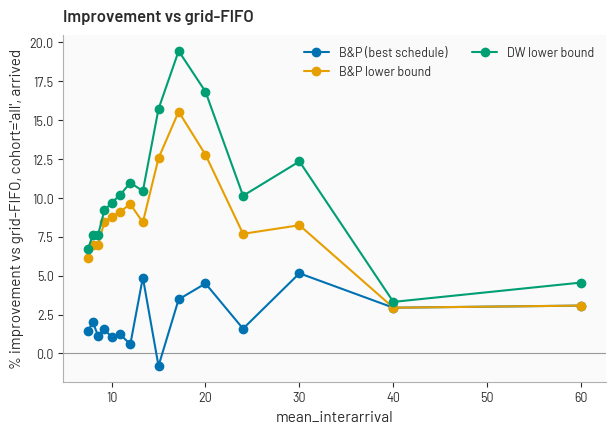

In [23]:
AS_PCT = True  # True: % of grid-FIFO; False: minutes saved (grid - M)

# Improvement vs grid-FIFO (same GROUP / COHORT as the plot cell).
#
# Mean sojourn is minutes per vehicle; lower is better. For a method M
# (exact incumbent, B&P schedule / lower bound, or DW lower bound),
#
#     abs_improvement = grid - M                         # minutes saved
#     pct_improvement = 100 * (grid - M) / grid          # share of grid removed
#
# AS_PCT chooses which of those the table and plot show. Positive means M
# is better than grid-FIFO.
#
# Exact's and B&P's schedule figures are improvements of a feasible schedule;
# on a TIME_LIMIT row they understate the true optimum's improvement. The
# lower bounds' figures (bp_LB, dw_LB <= z*) are *upper* bounds on how much
# the true optimum can beat grid-FIFO. Where bp_status is OPTIMAL the B&P
# schedule and lower bound coincide: that is the optimum's improvement.

grid_col = f"grid_{GROUP}_{COHORT}_mean_sojourn"
methods = [  # (column in df, short name, plot label)
    (f"exact_{GROUP}_{COHORT}_mean_sojourn", "exact", "exact MILP (incumbent)"),
    (f"bp_{GROUP}_{COHORT}_mean_sojourn", "bp", "B&P (best schedule)"),
    ("bp_mean_sojourn_LB", "bp_LB", "B&P lower bound"),
    ("dw_mean_sojourn_LB", "dw_LB", "DW lower bound"),
]
methods = [m for m in methods if m[0] in df.columns]

id_cols = [c for c in (X_AXIS, "max_time", "delta", "exact_status", "bp_status", "dw_status") if c in df.columns]
imp = df[id_cols].copy()
imp["grid"] = df[grid_col]
for col, name, _label in methods:
    imp[name] = df[col]
    saved = imp["grid"] - imp[name]
    imp[f"{name}_vs_grid"] = 100.0 * saved / imp["grid"] if AS_PCT else saved

imp = imp.sort_values(X_AXIS)
display(imp.round(2))

ylabel = (
    f"% improvement vs grid-FIFO, cohort='{COHORT}', {GROUP}"
    if AS_PCT
    else f"minutes saved vs grid-FIFO, cohort='{COHORT}', {GROUP}"
)
colors = palette(len(methods))
fig, ax = new_figure(figsize=(7, 4.5))
for (_col, name, label), color in zip(methods, colors):
    ax.plot(imp[X_AXIS], imp[f"{name}_vs_grid"], marker="o", color=color, label=label)
ax.axhline(0.0, color="0.6", lw=0.8, zorder=0)
ax.set_xlabel(X_AXIS)
ax.set_ylabel(ylabel)
style_axes(ax, title="Improvement vs grid-FIFO")
style_legend(ax, fontsize=7, ncol=2)
plt.show()

## How much of each row is censored?

The censored share is what decides whether a row is trustworthy. A row where
half the vehicles never finished is dominated by the censoring convention,
not by scheduling quality -- that is the regime where the `completed` and
`arrived` groups disagree most, and where a short `max_time` shows up.

`n_completed_at_horizon` counts vehicles that finished *exactly* at the
horizon edge (`D_j == K` yet fully charged). A nonzero count means the
horizon is binding on the optimum, and is also why completion is tested by
energy rather than by departure slot.

The table is read off the exact MILP's schedule when the run has it, else
off branch-and-price's (`SOURCE` below).

In [9]:
COHORT = "all"
SOURCE = "exact" if HAS_EXACT else "bp"  # whose schedule to read; set "bp" to see B&P's
cens = pd.DataFrame({
    "arrived_n": df[f"{SOURCE}_arrived_{COHORT}_n"],
    "completed_n": df[f"{SOURCE}_completed_{COHORT}_n"],
    "censored_n": df[f"{SOURCE}_arrived_{COHORT}_n_censored"],
})
cens["censored_share"] = cens["censored_n"] / cens["arrived_n"]
for col in (f"{SOURCE}_n_completed_at_horizon", f"{SOURCE}_n_at_horizon"):
    if col in df.columns:
        cens[col.replace(f"{SOURCE}_", "")] = df[col]
print(f"schedule: {SOURCE}")
cens.round(3)

schedule: bp


,arrived_n,completed_n,censored_n,censored_share,n_completed_at_horizon,n_at_horizon
0,51.0,13.0,38.0,0.745,0,38
1,49.0,13.0,36.0,0.735,0,36
2,40.0,12.0,28.0,0.700,0,28
3,37.0,13.0,24.0,0.649,0,24
4,35.0,13.0,22.0,0.629,0,22
5,28.0,13.0,15.0,0.536,0,15
6,26.0,13.0,13.0,0.500,0,13
7,13.0,6.0,7.0,0.538,0,7
8,19.0,13.0,6.0,0.316,0,6
9,17.0,13.0,4.0,0.235,0,4


## One trial's full detail

`results.csv` is the flattened view; `trials/trial_NNN.json` keeps the same
trial nested (and is where you'd look for anything `flatten_trial` didn't
pull into a column). That file also stores `arrivals`: the EV specs the DES
was fed, which is enough to rebuild the episode (`replay_episode` in the
next section). It does **not** store the env object, and it does **not**
include the per-vehicle schedule table (`ConnectorLaneSolution.per_vehicle` /
`PBSolution.per_vehicle` / `DWSolution.per_vehicle`) -- only the
aggregate/by-cohort figures `run_exact`/`run_bp`/`run_dw` returned.

In [10]:
TRIAL_ID = 0  # <-- edit to inspect a different row

trial = json.loads((run_dir / "trials" / f"trial_{TRIAL_ID:03d}.json").read_text())
print("config:", {k: v for k, v in trial["config"].items() if k in
      ("mean_interarrival", "max_time", "delta", "mip_gap", "gap_tolerance",
       "gap_tolerance_target_min", "boundary_mode", "objective_cohorts",
       "bp_time_limit", "bp_initial_schedule")})
print()
print("counts:  ", trial["counts"])
print("instance:", trial["instance"])
for stage in ("exact", "bp", "dw"):  # a stage the run skipped is None / absent
    print()
    print(f"{stage}:", trial.get(stage))

config: {'mean_interarrival': 7.5, 'max_time': 240, 'delta': 2.0, 'boundary_mode': 'optimize', 'objective_cohorts': 'boundary+measurement+queued', 'mip_gap': 0.001, 'gap_tolerance': 1e-06, 'gap_tolerance_target_min': 0.1, 'bp_time_limit': 1800.0, 'bp_initial_schedule': 'simulation'}

counts:   {'n_arrived_post_warmup': 28, 'n_queued_at_warmup_end': 21, 'n_in_service_at_warmup_end': 2, 'n_arrived_total': 69, 'n_finished_total': 31, 'n_dropped_total': 0, 'n_flushed_at_warmup': 0, 'sim_clock_end': 600.0, 'sim_runtime_s': 0.07043399987742305}
instance: {'n_vehicles': 51, 'n_dropped_late_arrivals': 0, 'late_arrival_ids': [], 'n_optimized': 51, 'n_boundary_vehicles': 2, 'n_discarded': 0, 'cohort_sizes': {'measurement': 28, 'queued': 21, 'boundary': 2}}

exact: None

bp: {'status': 'TIME_LIMIT', 'bound_history': [{'time_s': 0.36732660001143813, 'lower_bound': nan, 'upper_bound': 5373.0, 'gap': nan, 'gap_pct': nan, 'lower_bound_min': nan, 'upper_bound_min': 143.52941176470588, 'nodes': 0, 'eve

## Rebuild each trial and print utilization

`trials/trial_NNN.json` stores the arrival specs, not the env. This cell
rebuilds every trial (FIFO, proportional power -- the same rollout the sweep
ran) and prints connector utilization.

* `rho_sim` -- fraction of connector-time that was occupied.
* `rho_theory` -- `lambda_eff / (c * mu)`, with `lambda_eff = n_finished / T`
  and `mu = 1 / E[service]`.
* **full** is the whole clock, warm-up included. **measured** is
  `[warmup_period, T]`, the window the sojourn columns use.

A trial written before arrivals were saved is skipped. Re-run
`experiments.run_objective_sweep` to record them.

In [11]:
from experiments.objective_sweep import episode_utilization, replay_episode

rows = []
for trial_id in range(len(df)):
    path = run_dir / "trials" / f"trial_{trial_id:03d}.json"
    trial = json.loads(path.read_text())
    arrivals = trial.get("arrivals") or []
    cfg = trial["config"]
    tag = cfg.get("label") or ""
    if not arrivals:
        print(
            f"trial {trial_id} {tag}: no arrivals saved "
            "(re-run the sweep to record them)"
        )
        continue

    env = replay_episode(cfg, arrivals)
    full = episode_utilization(env, post_warmup=False)
    measured = episode_utilization(env, post_warmup=True)
    print(
        f"trial {trial_id} {tag}  interarrival={cfg['mean_interarrival']:g}  "
        f"full  rho_sim={full['rho_sim']:.3f}  rho_theory={full['rho_theory']:.3f}  "
        f"measured  rho_sim={measured['rho_sim']:.3f}  "
        f"rho_theory={measured['rho_theory']:.3f}"
    )
    rows.append(
        {
            "trial_id": trial_id,
            "label": tag,
            "mean_interarrival": cfg["mean_interarrival"],
            "max_time": cfg["max_time"],
            "rho_sim_full": full["rho_sim"],
            "rho_theory_full": full["rho_theory"],
            "rho_sim_measured": measured["rho_sim"],
            "rho_theory_measured": measured["rho_theory"],
            "n_finished_measured": measured["n_finished"],
        }
    )

pd.DataFrame(rows).round(3) if rows else print("nothing to replay")

trial 0 8veh  interarrival=7.5  full  rho_sim=0.938  rho_theory=0.917  measured  rho_sim=0.942  rho_theory=0.000
trial 1 7.5veh  interarrival=8  full  rho_sim=0.933  rho_theory=0.885  measured  rho_sim=0.975  rho_theory=0.000
trial 2 7veh  interarrival=8.57143  full  rho_sim=0.928  rho_theory=0.884  measured  rho_sim=0.973  rho_theory=0.000
trial 3 6.5veh  interarrival=9.23077  full  rho_sim=0.923  rho_theory=0.883  measured  rho_sim=0.949  rho_theory=0.000
trial 4 6veh  interarrival=10  full  rho_sim=0.917  rho_theory=0.881  measured  rho_sim=0.975  rho_theory=0.000
trial 5 5.5veh  interarrival=10.9091  full  rho_sim=0.910  rho_theory=0.886  measured  rho_sim=0.963  rho_theory=0.158
trial 6 5veh  interarrival=12  full  rho_sim=0.900  rho_theory=0.878  measured  rho_sim=0.967  rho_theory=0.491
trial 7 4.5veh/2  interarrival=13.3333  full  rho_sim=0.863  rho_theory=0.829  measured  rho_sim=0.826  rho_theory=0.000
trial 8 4veh  interarrival=15  full  rho_sim=0.862  rho_theory=0.839  meas

,trial_id,label,mean_interarrival,max_time,rho_sim_full,rho_theory_full,rho_sim_measured,rho_theory_measured,n_finished_measured
0,0,8veh,7.500,240,0.938,0.917,0.942,0.000,0.0
1,1,7.5veh,8.000,240,0.933,0.885,0.975,0.000,0.0
2,2,7veh,8.571,240,0.928,0.884,0.973,0.000,0.0
3,3,6.5veh,9.231,240,0.923,0.883,0.949,0.000,0.0
4,4,6veh,10.000,240,0.917,0.881,0.975,0.000,0.0
5,5,5.5veh,10.909,240,0.910,0.886,0.963,0.158,2.0
6,6,5veh,12.000,240,0.900,0.878,0.967,0.491,6.0
7,7,4.5veh/2,13.333,120,0.862,0.829,0.826,0.000,0.0
8,8,4veh,15.000,240,0.862,0.839,0.905,0.664,9.0
9,9,3.5veh,17.143,240,0.777,0.746,0.958,0.881,12.0


## Notes / gotchas (see `experiments/README.md` for the full version)

- **`sim` is not the target.** The offline models can only depart on `delta`
  slot boundaries; compare against `grid`, not `sim`.
- **`exact` and `bp` are the same model.** The compact MILP and
  branch-and-price solve one whole-module problem two ways. Where both say
  `OPTIMAL` their objectives agree; on a `TIME_LIMIT` row each gives a valid
  bracket (`*_best_bound` <= optimum <= `*_objective`), and B&P's lower
  bound is usually much tighter.
- **DW and B&P have no per-cohort lower bound.** `dw_mean_sojourn_LB` and
  `bp_mean_sojourn_LB` certify whichever `objective_cohorts` that trial was
  solved over as a whole -- not a separate bound for `measurement` vs.
  `all`. If you need a bound for one cohort specifically, that cohort must
  be `objective_cohorts` for its own trial.
- **Watch the `n` columns** (`sim_{cohort}_n`, `grid_{cohort}_n`,
  `exact_{cohort}_n`, `bp_{cohort}_n`, `dw_n_optimized`) when comparing
  `sim`/`grid` against the models: the simulation only counts vehicles that
  *finished* inside the run, the offline models count every vehicle they
  were given. Different `n` means different populations -- the mean-sojourn
  gap is not apples-to-apples until `max_time` is long enough that these
  line up.
- **Every trial sharing a `seed` sees the same EV population**, on every
  swept axis -- `generate_arrivals` draws inter-arrival gaps and vehicle
  characteristics from separate streams, so vehicle *k*'s battery/SoC
  depend only on *k*. A sweep varies the arrival process alone rather
  than resampling the fleet underneath it. (This replaces the old
  `arrival_horizon` knob, now removed.) Holding `delta_arr` fixed keeps
  the alignment exact -- see the README, "Common random numbers across a
  sweep".